In [1]:
import os
import time
import numpy as np
from matplotlib import pyplot as plt
from examples.seismic.utils import taper_wavelet, estimate_centroid_frequency_gather
from examples.seismic import SeismicModel, AcquisitionGeometry
from examples.seismic.acoustic import AcousticWaveSolver, EikonalSolver
from examples.seismic.plotting import plot_two_wavelets, overlay_wiggle_plot, wiggle_plot
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from examples.seismic.wavelet_inversion import wiener_deconvolution
from devito import info, configuration


configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"
configuration["compiler"] = "pgcc"

PATH_MODEL = "../data/South_ForMigr_2.dat"
PATH_DATA = path = "../data/21-20.sgy"
SO = 4
WAVELET = "Ricker"
NBL = 500

In [ ]:
dataset = SeismogramDataset(PATH_DATA, "sou", invert_elevs=True)
xmin, xmax = min(dataset.x_coords.min(), dataset.opposite_x.min()), max(dataset.x_coords.max(), dataset.opposite_x.max())
spacing = (0.025, 0.025)
velmodel = VelocityModel(PATH_MODEL, dx=spacing[0], dz=spacing[1], clip=True, xmin=xmin-3, xmax=xmax+3, zmin=-318)
velmodel.pad_left(4)
velmodel.pad_right(8*int(0.5/spacing[0]))
velmodel.pad_bottom(10*int(0.5/spacing[0]))
velmodel.pad_top(7*int(0.5/spacing[0]))

origin = velmodel.x[0], velmodel.z[0]
vp = velmodel.vp.T


model = SeismicModel(
    vp=vp,
    origin=origin,
    shape=vp.shape,
    spacing=spacing,
    space_order=SO,
    nbl=NBL,
    bcs="damp",
    fs=False,
)
t0 = 0.0
tn = dataset._t_max
dataset.dt_r = model.critical_dt
dataset.t_max_r = tn
dataset.resample_on()

f0 = 0.25

for i in range(len(dataset)):
    info(f"Inverting {i+1}-th gather wavelet")
    d_2, sx, sz, rec_x, rec_z = dataset[i]
    # d_2 *= -1
    f0 = estimate_centroid_frequency_gather(d_2.T, model.critical_dt) / 1e3
    info(f"Estimated gather centroid frequency: {f0*1e3:.2f} Hz, Wavelet length: {1/f0:.2f} ms")

    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    f0 = f0 if WAVELET == "Ricker" else f0*2.5
    geometry = AcquisitionGeometry(model, rec_pos, src_pos, t0, tn, f0=f0*2, src_type=WAVELET)
    solver = AcousticWaveSolver(model, geometry, space_order=SO)

    d_1, _, _ = solver.forward(vp=model.vp, save=False)
    
    wav1 = geometry.src.data
    
    # fig, ax = overlay_wiggle_plot(
    #     np.array(d_1.data[:]), d_2.T, time_axis=geometry.time_axis.time_values, xrec=rec_z, title="Original vs Processed"
    # )
    # plt.show()

    
    eikonal = EikonalSolver(velmodel, dataset)
    _, hodograph = eikonal.solve_single(i)
    hodograph_samples = (hodograph/model.critical_dt).astype('int')
    
    tap_t0 = 1/f0 if WAVELET == "Ricker" else 2/f0
    stf, d_obs_used, d_mod_used, rec_z_used = wiener_deconvolution(
        d_2.T, d_1.data, sz, rec_z,
        time_axis=geometry.time_axis.time_values,
        first_breaks=hodograph_samples,
        eps=1e-1, normalize=True,
        kill_offset=True,
        offset_threshold=10,
        taper_before=5,
        taper_after=tap_t0*1.2,
    )
    
    # fig, ax = overlay_wiggle_plot(
    #     d_mod_used, d_obs_used, time_axis=geometry.time_axis.time_values, xrec=rec_z, title="Original vs Processed"
    # )
    # plt.show()
    
    wav3 = np.convolve(wav1.squeeze(), stf)[: d_1.shape[0]]
    #         
    wav3_tapered, taper = taper_wavelet(wav3, geometry.time_axis.time_values, 1.2*tap_t0, 0.5 * tap_t0)
    #         normstr = "norm" if norm else "nonnorm"
    #         killstr = "kill" if kill else "nonkill"
    np.save(f"conditional_wavelets/{i+1}.npy", wav3_tapered)

    # geometry = AcquisitionGeometry(model, rec_pos, src_pos, t0, tn, f0=f0 * 2, src_type=None, wav_data=wav3_tapered)
    # solver = AcousticWaveSolver(model, geometry, space_order=SO)
    # d_3, _, _  = solver.forward(vp=model.vp, src=geometry.src, save=False)

    fig, axs = plot_two_wavelets(geometry.time_axis.time_values, wav1, wav3_tapered, taper)
    plt.show()
    # fig, ax = overlay_wiggle_plot(
    #     np.array(d_3.data[:]), d_2.T, time_axis=geometry.time_axis.time_values, xrec=rec_z, title="Original vs Processed"
    # )
    # ax.plot(rec_z, hodograph, c='cyan')
    # plt.show()

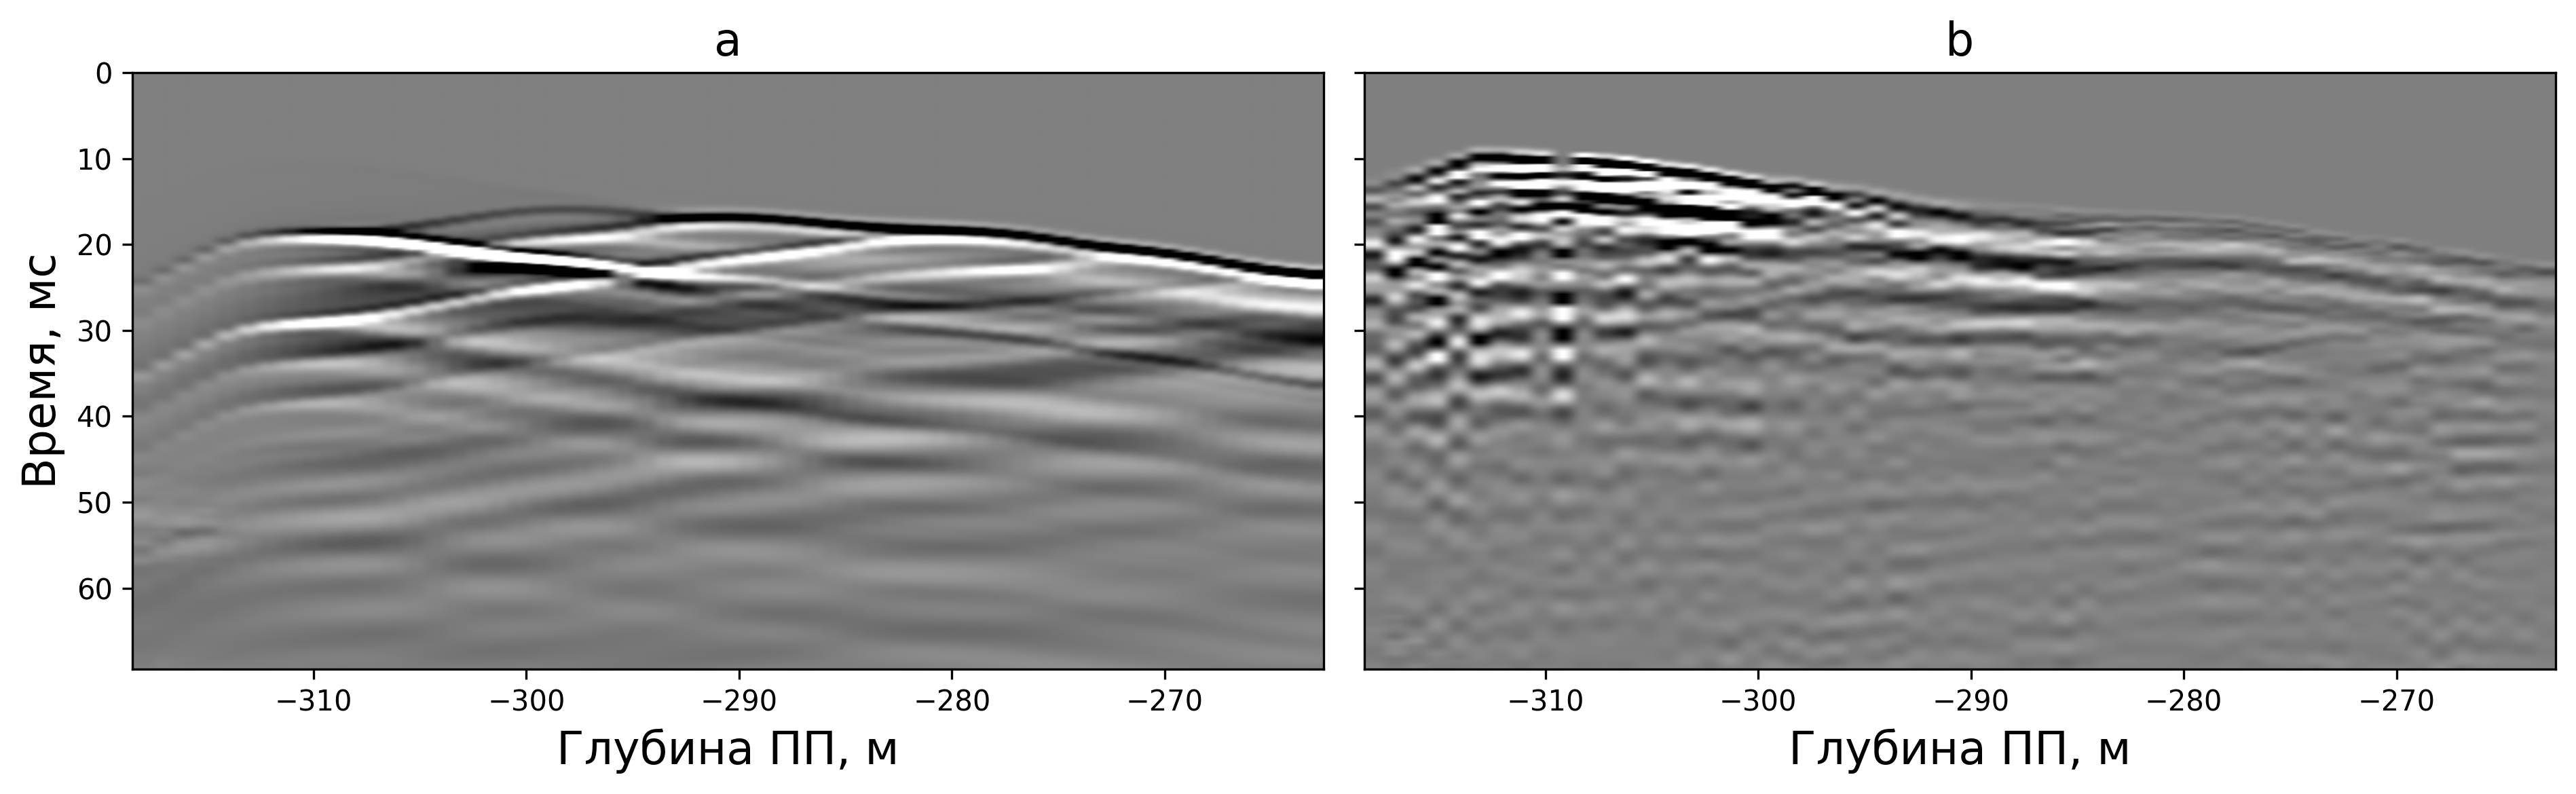

In [6]:
from examples.seismic.plotting import plot_seis_double_hor
fig, axs = plot_seis_double_hor(np.array(d_3.data[:]), d_2.T, time_range=geometry.time_axis.time_values, z=rec_z, titles=['a', 'b'], show=False)
plt.show()